In [2]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# filter through isophotal


In [ ]:
cl.columns

Index(['id', 'random_idx', 'ra', 'dec', 'field', 'a_pixel_det',
       'a_restricted_pixel_r', 'b_pixel_det', 'b_restricted_pixel_r',
       'class_star_det',
       ...
       's2n_pstotal_j0660', 's2n_pstotal_j0861', 's2n_pstotal_r',
       's2n_pstotal_u', 's2n_pstotal_z', 'theta_det', 'x_pixel_det',
       'y_pixel_det', 'splus_idr6_id', 'AstroInspectClass'],
      dtype='object', length=444)

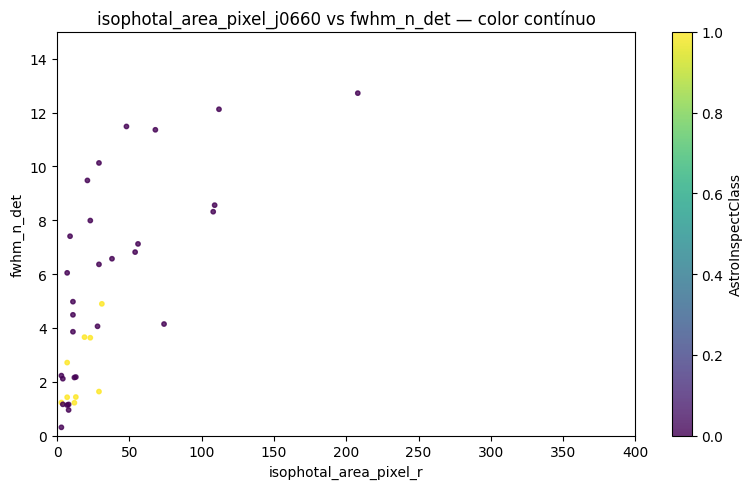

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# caso AstroInspectClass seja numérica (ou transformar para num)
vals = cl['AstroInspectClass'].astype(float)  # cuidado com NaNs/strings

plt.figure(figsize=(8,5))
sc = plt.scatter(cl['isophotal_area_pixel_i'], cl['fwhm_n_det'], c=vals, cmap='viridis', s=10, alpha=0.8)
plt.gca().invert_yaxis()
plt.xlabel('isophotal_area_pixel_r')
plt.ylabel('fwhm_n_det')
plt.title('isophotal_area_pixel_j0660 vs fwhm_n_det — color contínuo')
plt.ylim(0,15)
plt.xlim(0,400)
plt.colorbar(sc, label='AstroInspectClass')
plt.tight_layout()
plt.show()

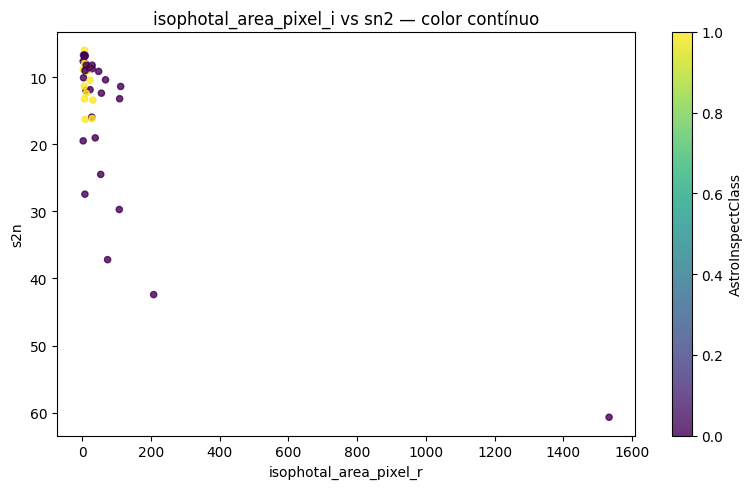

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# caso AstroInspectClass seja numérica (ou transformar para num)
vals = cl['AstroInspectClass'].astype(float)  # cuidado com NaNs/strings

plt.figure(figsize=(8,5))
sc = plt.scatter(cl['isophotal_area_pixel_i'], cl['s2n_psf_i'], c=vals, cmap='viridis', s=20, alpha=0.8)
plt.gca().invert_yaxis()
plt.xlabel('isophotal_area_pixel_r')
plt.ylabel('s2n')
plt.title('isophotal_area_pixel_i vs sn2 — color contínuo')

plt.colorbar(sc, label='AstroInspectClass')
plt.tight_layout()
plt.show()

# filtering distances

In [3]:
marks = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv')

/tmp/ipykernel_7259/1485448797.py:1: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  marks = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv')


In [5]:
len(marks[marks['h_alpha_emitters_8sigma'] ==1]['id'].unique())

42540

In [6]:
emitters = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all_dist.csv')

In [7]:
emitters['id'].nunique()

42540

In [8]:
emitters

,Unnamed: 0,id_x,ra_x,dec_x,parallax_x,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,...,gaia_id,ra_y,dec_y,pmra,pmdec,pmra_error,pmdec_error,parallax_y,parallax_error,phot_g_mean_mag
0,0,b'i06MC007700QSM',37.204273,-70.742390,14.850342,1.106129,1364.524900,0.992964,0,0,...,4645248099765187200,37.204440,-70.742415,-5.390555,7.497611,0.016246,0.012558,14.850342,0.010883,13.604811
1,1,b'i06MC007700W87',37.665234,-70.546030,7.107466,1.093844,462.059020,0.000001,0,0,...,4645344925508069376,37.665285,-70.546090,33.696208,7.582918,0.019999,0.018365,7.107466,0.015382,14.632010
2,2,b'i06MC007700YB8',37.323734,-70.473015,5.347390,1.065020,474.439200,0.998258,0,0,...,4645393029141774720,37.323927,-70.473103,3.586887,25.913498,0.013539,0.013539,5.347390,0.011271,13.962221
3,3,b'i06MC007700ZEO',37.238150,-70.431280,5.590915,1.060642,406.684780,0.996487,0,0,...,4645394128653396864,37.238275,-70.431361,36.260203,16.166004,0.016658,0.015330,5.590915,0.013748,14.373489
4,4,b'i06MC01390018K',36.038734,-75.364100,0.853479,1.020283,10.123593,0.999961,0,0,...,4634203913485331584,36.038595,-75.364015,-0.924506,-6.279665,0.123386,0.105398,0.853478,0.084306,17.854486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43291,43291,b'i06MC00870G60V',81.166885,-70.233320,-0.203989,1.009526,-1.602085,1.000000,0,0,...,4657931580600225024,81.166853,-70.233354,1.582878,0.675687,0.179475,0.167311,-0.203989,0.127327,18.641092
43292,43292,b'i06MC00870G62Y',81.347560,-70.234480,0.049941,1.142184,0.353941,0.999984,0,0,...,4657928797633341824,81.347661,-70.234513,2.383661,0.410661,0.190510,0.207644,0.049941,0.141101,18.543268
43293,43293,b'i06MC00870G6GB',81.343445,-70.238310,0.050822,1.302804,0.266321,0.999994,0,0,...,4657928797633339392,81.343259,-70.238357,1.577267,-0.222219,0.262038,0.279294,0.050822,0.190830,18.809166
43294,43294,b'i06MC00870G6GT',81.342370,-70.239070,0.171245,1.081208,1.047559,0.999999,0,0,...,4657928419676919296,81.342288,-70.239092,1.875049,0.709178,0.221231,0.244536,0.171245,0.163470,18.744604


In [9]:
dist = emitters[emitters['r_med_photogeo'] >= 6000]

In [17]:
dist['id']

5        i06MC013900E66
6        i06MC013900WOW
7        i06MC013900ZG9
8        i06MC01390108M
11       i06MC013900SYU
              ...      
43282    i06MC00870EULC
43283    i06MC00870ALAD
43284    i06MC00870DKB7
43285    i06MC00870DS1P
43295    i06MC00870G74I
Name: id, Length: 22805, dtype: object

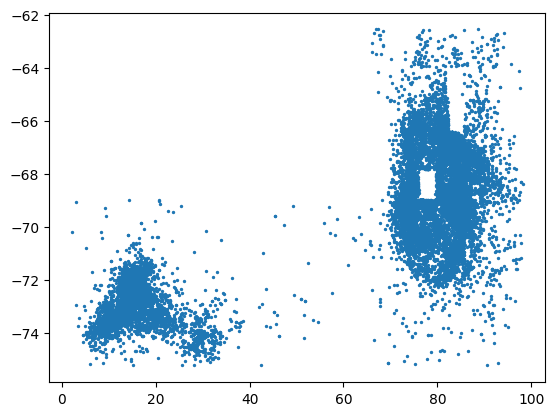

In [13]:
plt.scatter(dist['ra_y'], dist['dec_y'], s =2)

(3.0, -5.0)

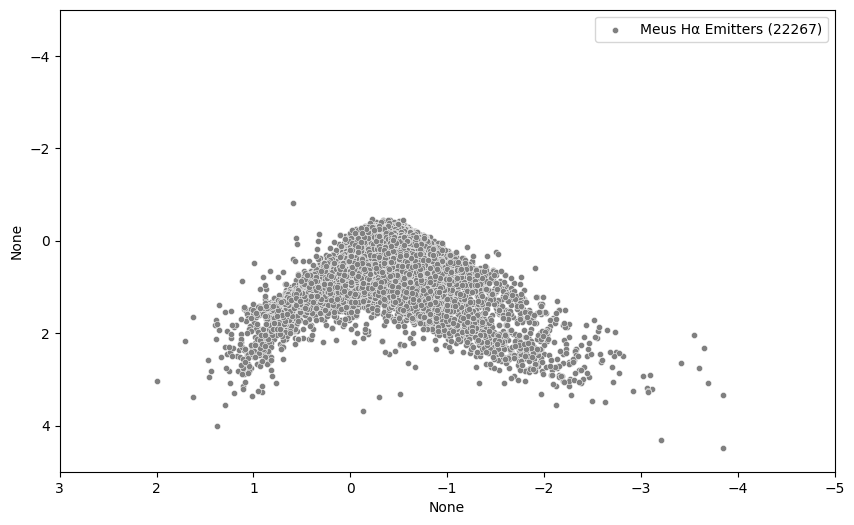

In [15]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(y=dist['mag_psf_j0515'] - dist['mag_psf_j0660'], 
                x=dist['mag_psf_j0660'] - dist['mag_psf_j0861'], 
                label=f'Meus Hα Emitters ({len(dist["id"].unique())})', color='gray', s=20)

plt.ylim(5, -5)
plt.xlim(3, -5)

In [18]:
marks['emitters_distance_cut'] = marks['id'].isin(dist['id'])

In [19]:
marks.to_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv', index=False)